# Single Step Reverse Diffusion with a U-net

In this notebook, we do train a U-net network to learn how noise has been added to an image. We later do a single pass of the reverse diffusion process and try to reconstruct the original image out of pure noise. The network is trained using per-pixel mean squared error loss between the original and corrupted images.

In [ ]:
# this allows to produce visualizations of the unet architecture
%%capture
!uv pip install torchview

In [ ]:
import torchview
import torch
torchview.__version__

'0.2.7'

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

# Visualization tools
import graphviz
from torchview import draw_graph
import torchvision
# I use a newer version of transforms
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt

In [ ]:
train_set = torchvision.datasets.MNIST(root='./data',
                                       train=True, download=True,
                                       # this replaces ToTensor(), which is currently deprecated
                                       transform=transforms.Compose([
                                           transforms.ToImage(),
                                           transforms.ToDtype(torch.float32, scale=True)
                                           ]
                                       ))


NUM_CLASSES = 10


100%|██████████| 9.91M/9.91M [00:00<00:00, 54.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.7MB/s]


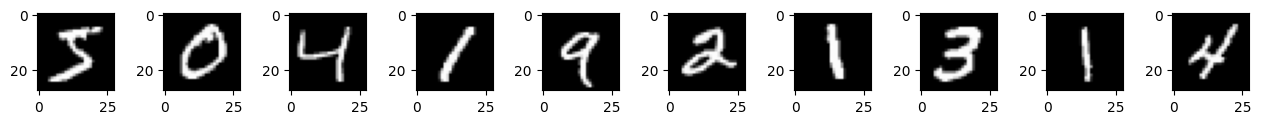

In [ ]:
# Adjust for display; high w/h ratio recommended
plt.figure(figsize=(16, 1))

def show_images(dataset, num_samples=10):
    for i, img in enumerate(dataset):
        if i == num_samples:
            return
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(torch.squeeze(img[0]), cmap="gray")

show_images(train_set)

In [ ]:
train_set[0][0].min(), train_set[0][0].max()

(tensor(0.), tensor(1.))

In [ ]:
train_set[0][0].shape

torch.Size([1, 28, 28])

In [ ]:
IMG_SIZE = 16 # Due to stride and pooling, must be divisible by 2 multiple times
IMG_CH = 1 # Black and white image, no color channels
BATCH_SIZE = 128

In [ ]:
def load_MNIST(data_transform, train=True):
    return torchvision.datasets.MNIST(
        "./",
        download=True,
        train=train,
        transform=data_transform,
    )


def load_transformed_MNIST():
    data_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                         transforms.ToImage(),
                                         transforms.ToDtype(torch.float32, scale=True),  # Scales data into [0,1]
                                        # we do this because the neural networks is initialized with weights that are also approximately [-1, 1]
                                        # due to He initialization https://docs.pytorch.org/docs/stable/nn.init.html
                                        transforms.Lambda(lambda t: (t * 2) - 1)])  # Scale between [-1, 1])

    train_set = load_MNIST(data_transform, train=True)
    test_set = load_MNIST(data_transform, train=False)
    return torch.utils.data.ConcatDataset([train_set, test_set])


In [ ]:
data = load_transformed_MNIST()
len(data)

100%|██████████| 9.91M/9.91M [00:00<00:00, 64.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]


70000

In [ ]:
# the dataloader splits the images into batches
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [ ]:
images, labels = next(iter(dataloader))
images.shape

torch.Size([128, 1, 16, 16])

In [ ]:
labels.shape

torch.Size([128])

In [ ]:
labels

tensor([5, 5, 4, 6, 5, 1, 8, 2, 5, 7, 2, 0, 5, 9, 1, 2, 4, 4, 5, 9, 1, 0, 1, 6,
        1, 7, 2, 2, 5, 2, 7, 2, 4, 1, 2, 2, 8, 2, 8, 9, 3, 1, 1, 8, 9, 0, 4, 4,
        2, 7, 1, 8, 4, 1, 3, 4, 3, 3, 9, 2, 6, 4, 0, 5, 2, 1, 0, 0, 5, 3, 6, 8,
        9, 6, 9, 5, 6, 8, 3, 6, 3, 5, 6, 2, 7, 5, 9, 6, 2, 7, 3, 4, 2, 9, 9, 5,
        1, 9, 7, 7, 5, 6, 8, 1, 3, 7, 8, 3, 7, 7, 9, 6, 4, 4, 7, 6, 4, 7, 3, 8,
        2, 9, 1, 6, 4, 5, 3, 3])

In [ ]:
conv_demo = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=(3,3), stride=1, padding=1)
max_pool_demo = nn.MaxPool2d(kernel_size=(2,2), stride=2)

In [ ]:
conv_demo.weight

Parameter containing:
tensor([[[[-0.2087, -0.1785,  0.0335],
          [ 0.1266,  0.2164,  0.2081],
          [ 0.1783, -0.0488, -0.2841]]],


        [[[ 0.3167, -0.2777,  0.2862],
          [ 0.0082, -0.2826,  0.0230],
          [-0.1564, -0.3249,  0.3206]]],


        [[[ 0.0387, -0.2521, -0.1032],
          [-0.0748, -0.1289, -0.0227],
          [ 0.2564,  0.0104,  0.0964]]],


        [[[-0.3200,  0.1689,  0.0354],
          [-0.1831, -0.1079, -0.2012],
          [ 0.1547, -0.2023,  0.2647]]],


        [[[ 0.2535,  0.2630,  0.2585],
          [ 0.0394, -0.3222,  0.3156],
          [-0.1181, -0.0251, -0.2772]]],


        [[[ 0.1483,  0.0533,  0.1428],
          [-0.2921,  0.2851,  0.0397],
          [ 0.1099,  0.3036, -0.0489]]],


        [[[-0.1384,  0.1712, -0.2554],
          [ 0.2140,  0.3142, -0.2631],
          [-0.3203,  0.0919,  0.1799]]],


        [[[-0.1506, -0.0183, -0.1576],
          [ 0.0387, -0.3083, -0.2223],
          [ 0.3171,  0.1159, -0.1235]]],


        [[

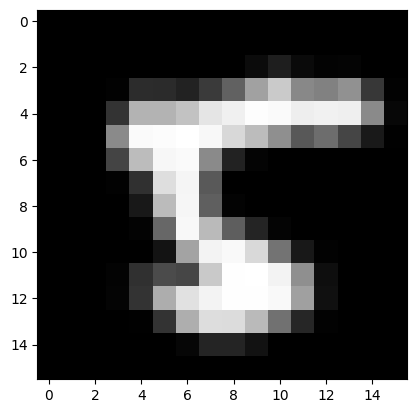

In [ ]:
plt.imshow(images[0].squeeze(), cmap='gray');

In [ ]:
output_conv_demo = conv_demo(images[0])
output_conv_demo.shape

torch.Size([64, 16, 16])

In [ ]:
output_max_pool_demo = max_pool_demo(output_conv_demo)
output_max_pool_demo.shape

torch.Size([64, 8, 8])

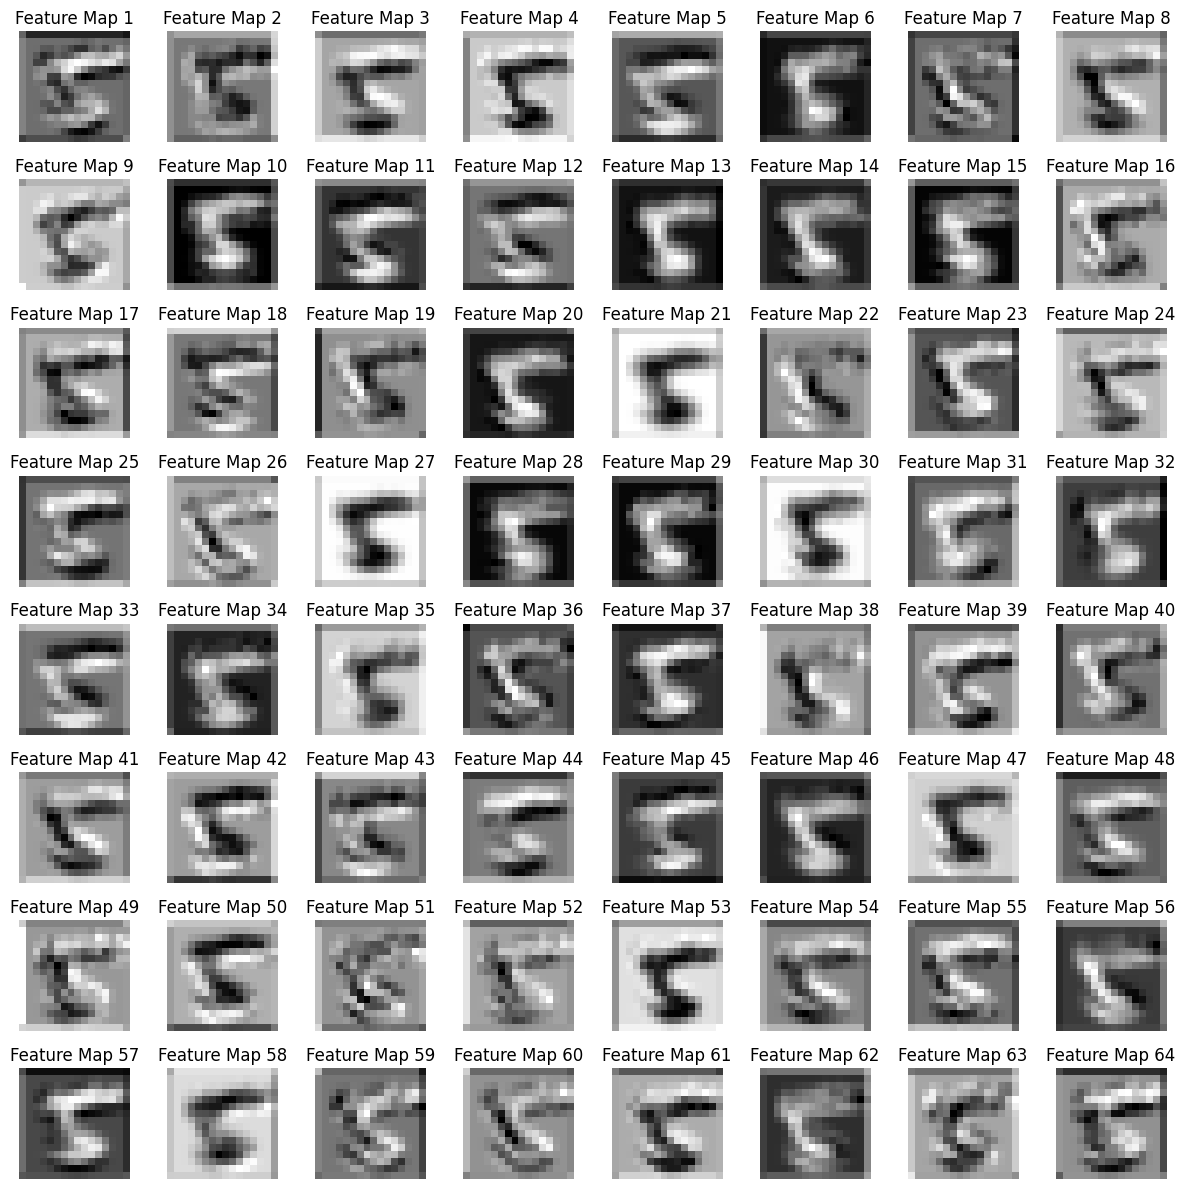

In [ ]:
# Visualize the output feature maps
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(output_conv_demo[i].detach().numpy(), cmap='gray')
    ax.set_title(f'Feature Map {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

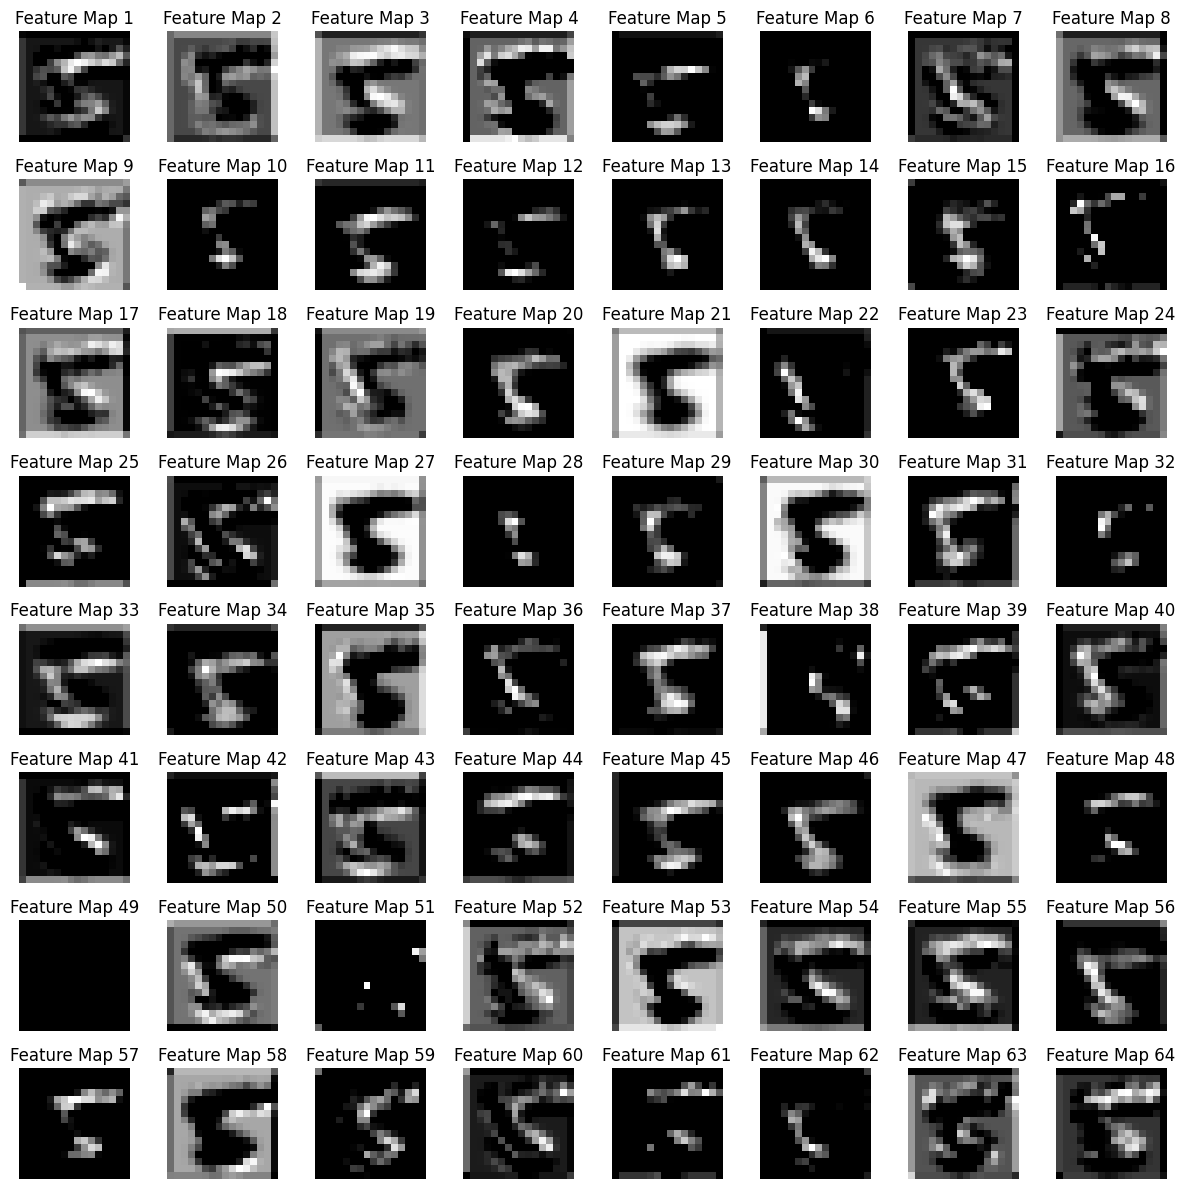

In [ ]:
# Visualize the output feature maps
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(F.relu(output_conv_demo[i]).detach().numpy(), cmap='gray')
    ax.set_title(f'Feature Map {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

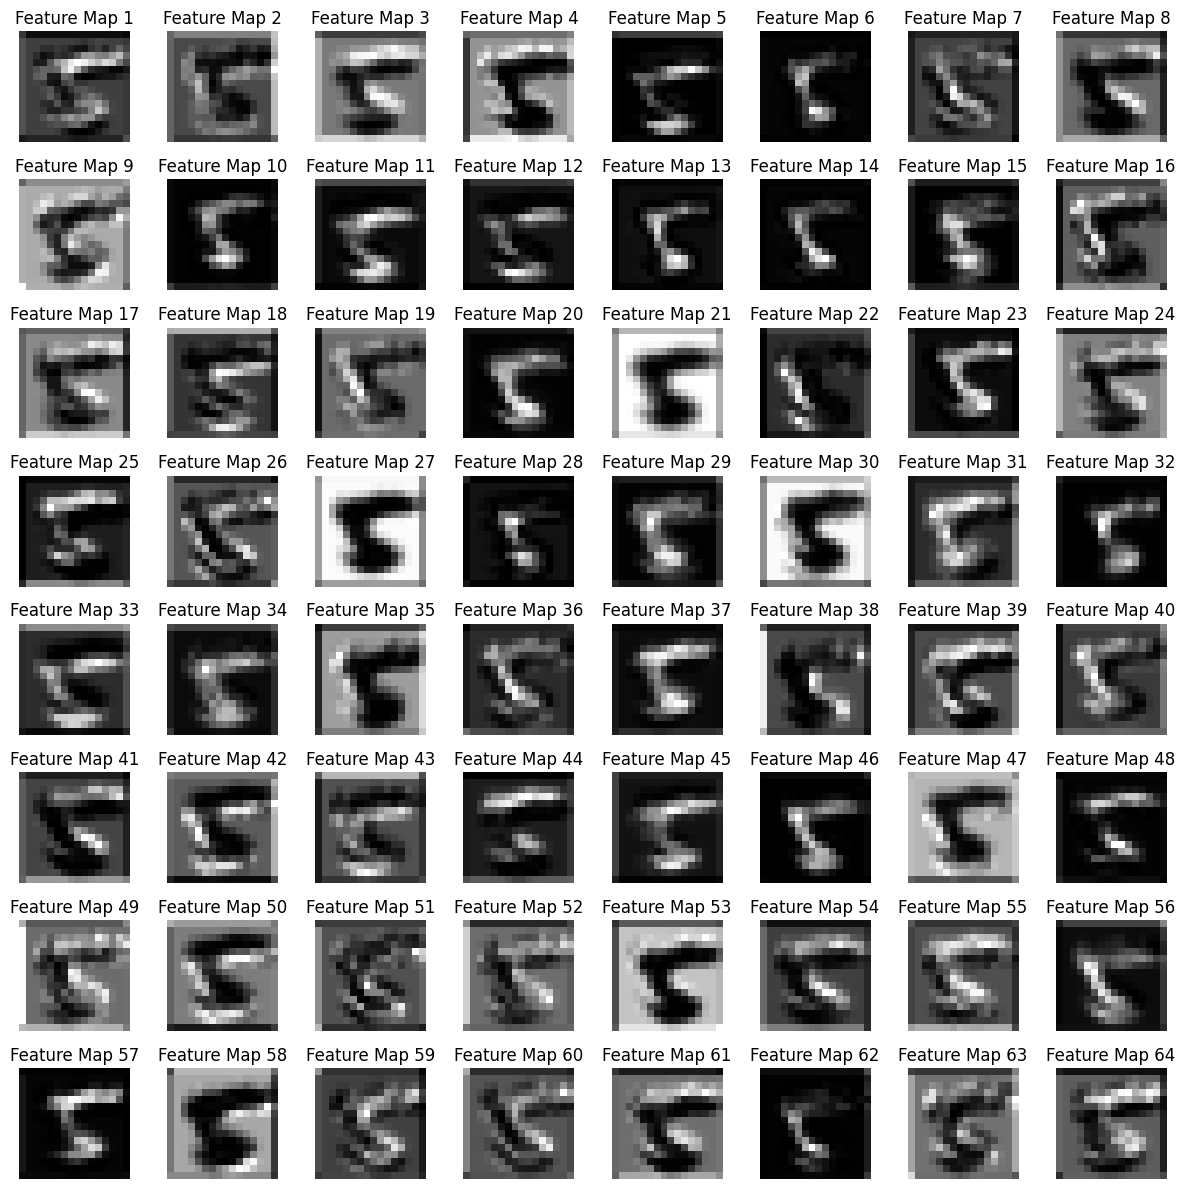

In [ ]:
# Visualize the output feature maps
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(F.gelu(output_conv_demo[i]).detach().numpy(), cmap='gray')
    ax.set_title(f'Feature Map {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

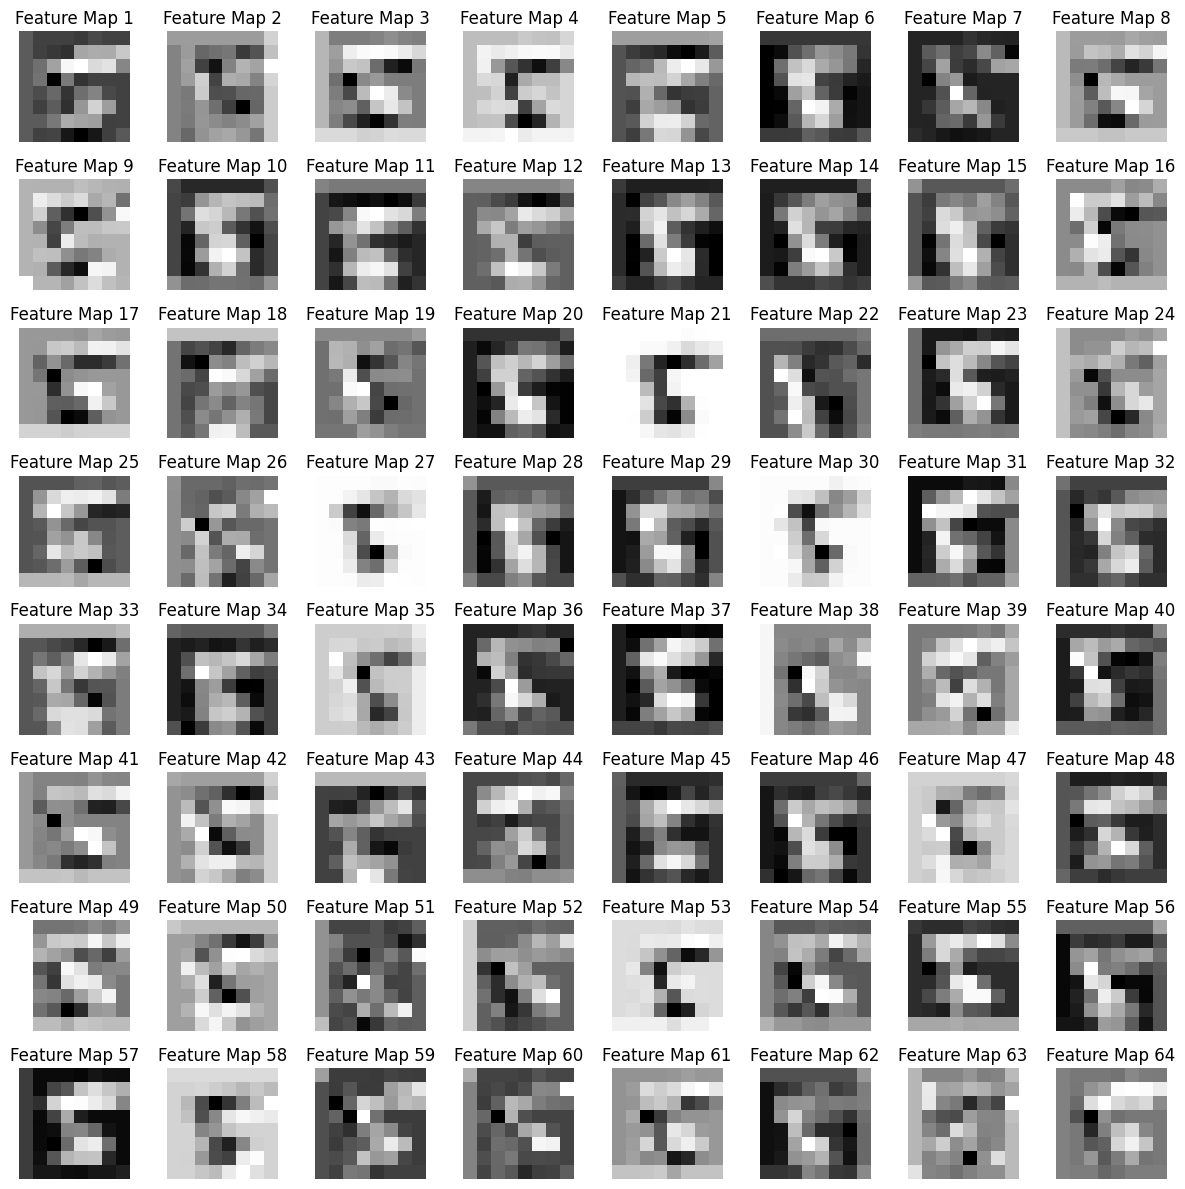

In [ ]:
# Visualize the output feature maps
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(output_max_pool_demo[i].detach().numpy(), cmap='gray')
    ax.set_title(f'Feature Map {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        kernel_size = 3
        stride = 1
        padding = 1

        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.MaxPool2d(2)
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
in_ch = 1
out_ch = 64
kernel_size = 3
stride = 1
padding = 1
nn.Sequential( nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
                nn.BatchNorm2d(out_ch),
                  nn.ReLU(),
                  nn.Conv2d(out_ch, out_ch, kernel_size, stride, padding),
                  nn.BatchNorm2d(out_ch),
                  nn.ReLU(),
                  nn.MaxPool2d(2))

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [ ]:
down_block = DownBlock(1, 64)
down_block

DownBlock(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)

In [ ]:
ch, h, w = 1, 3, 3
x = torch.ones(1, ch, h, w)
x

tensor([[[[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]]]])

In [ ]:
kernel = torch.tensor([[1.]])  # Identity kernel
kernel = kernel.view(1, 1, 1, 1).repeat(1, 64, 1, 1) # Make into a batch

kernel.shape

torch.Size([1, 64, 1, 1])

In [ ]:
output = F.conv_transpose2d(x, kernel, stride=1, padding=0, output_padding=0)[0]
output.shape

torch.Size([64, 3, 3])

In [ ]:
kernel_size = 3
kernel = torch.ones(1, 1, kernel_size, kernel_size)

output = F.conv_transpose2d(x, kernel, stride=1, padding=0,
                            output_padding=0, dilation=1)[0]
output.shape

torch.Size([1, 5, 5])

In [ ]:
F.conv_transpose2d?

In [ ]:
class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        # Convolution variables
        kernel_size = 3
        stride = 1
        padding = 1

        # Transpose variables
        strideT = 2
        out_paddingT = 1

        super().__init__()
        # 2 * in_chs for concatednated skip connection
        layers = [
            nn.ConvTranspose2d(2 * in_ch, out_ch, kernel_size, strideT, padding, out_paddingT),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        x = self.model(x)
        return x

In [ ]:
IMG_SIZE // 4

4

![](https://github.com/andandandand/practical-computer-vision/blob/main/images/unet-from-notebook.png?raw=true)

### Understanding the `dense_emb` Layer

At the center of this U-Net, the feature map is at its lowest spatial resolution and highest channel depth.  
This layer, named **`dense_emb`**, acts as a bridge between the downsampling and upsampling paths.

The tensor that arrives at this point has the shape:

$$
[B, C, H, W]
$$

where **B** is the batch size, **C** the number of channels, and **H**, **W** the spatial dimensions.  
The model flattens this tensor into a vector of size:

$$
[B, C \times H \times W]
$$

This flattened vector is passed through several **fully connected (linear)** layers:

$$
z' = f_3(\text{ReLU}(f_2(\text{ReLU}(f_1(z)))))
$$

where each  $f_i$ is a linear transformation.  
These layers allow information to mix globally across all pixels, something convolutional layers cannot do efficiently because they operate locally.

After processing, the vector is reshaped back to the original spatial layout:

$$
[B, C, H, W]
$$

This operation gives the network a wider receptive field and enables it to learn relationships that span the entire image.  
In diffusion models, a similar mechanism is used to inject **timestep** or **conditioning embeddings** at the bottleneck.  
Here, the dense block serves as a simplified way to introduce that idea by allowing the U-Net to reason about the whole latent image before reconstruction begins.


### Suggestion: use `pdb.set_trace()` to inspect the output of the forward pass

[Python Debugger Basics](https://www.youtube.com/watch?v=P0pIW5tJrRM)

### Experiment: check the dimensions of the output. Use `pdb.set_trace()` to inspect the `forward()` pass. Be sure to call `.shape` on each of the tensors.

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        img_ch = IMG_CH
        down_chs = (16, 32, 64)
        up_chs = down_chs[::-1]  # Reverse of the down channels
        latent_image_size = IMG_SIZE // 4 # 2 ** (len(down_chs) - 1)

        # Inital convolution
        self.down0 = nn.Sequential(
            nn.Conv2d(img_ch, down_chs[0], 3, padding=1),
            nn.BatchNorm2d(down_chs[0]),
            nn.ReLU()
        )

        # Downsample
        self.down1 = DownBlock(down_chs[0], down_chs[1])
        self.down2 = DownBlock(down_chs[1], down_chs[2])
        self.to_vec = nn.Sequential(nn.Flatten(), nn.ReLU())

        # Embeddings
        self.dense_emb = nn.Sequential(
            nn.Linear(down_chs[2]*latent_image_size**2, down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[2]*latent_image_size**2),
            nn.ReLU()
        )

        # Upsample
        self.up0 = nn.Sequential(
            nn.Unflatten(1, (up_chs[0], latent_image_size, latent_image_size)),
            nn.Conv2d(up_chs[0], up_chs[0], 3, padding=1),
            nn.BatchNorm2d(up_chs[0]),
            nn.ReLU(),
        )
        self.up1 = UpBlock(up_chs[0], up_chs[1])
        self.up2 = UpBlock(up_chs[1], up_chs[2])

        # Match output channels
        self.out = nn.Sequential(
            nn.Conv2d(up_chs[-1], up_chs[-1], 3, 1, 1),
            nn.BatchNorm2d(up_chs[-1]),
            nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_ch, 3, 1, 1),
        )

    def forward(self, x):
        # Experiment: check the dimensions of the output
        # use pdb.set_trace() to inspect the forward() pass
        # be sure to call .shape on each of these tensors
        import pdb; pdb.set_trace()

        down0 = self.down0(x)
        down1 = self.down1(down0)
        down2 = self.down2(down1)
        latent_vec = self.to_vec(down2)

        up0 = self.up0(latent_vec)
        up1 = self.up1(up0, down2)
        up2 = self.up2(up1, down1)
        return self.out(up2)


In [ ]:
model = UNet()
model_viz = UNet().to("cpu")
model = model.to(device)
print("Num params: ", sum(p.numel() for p in model.parameters()))

Num params:  234977


In [ ]:
graphviz.set_jupyter_format('png')
model_graph = draw_graph(
    model_viz,
    input_size=(BATCH_SIZE, IMG_CH, IMG_SIZE, IMG_SIZE),
    device='meta',
    expand_nested=True
)
model_graph.resize_graph(scale=1.5)
model_graph.visual_graph

> /tmp/ipython-input-1997052945.py(55)forward()
     53         import pdb; pdb.set_trace()
     54 
---> 55         down0 = self.down0(x)
     56         down1 = self.down1(down0)
     57         down2 = self.down2(down1)

ipdb> n
> /tmp/ipython-input-1997052945.py(56)forward()
     54 
     55         down0 = self.down0(x)
---> 56         down1 = self.down1(down0)
     57         down2 = self.down2(down1)
     58         latent_vec = self.to_vec(down2)

ipdb> x.shape
torch.Size([128, 1, 16, 16])
ipdb> down.shape
*** Newest frame
ipdb> down0.shape
torch.Size([128, 16, 16, 16])


In [ ]:
def add_noise(imgs,percent=0.5):
  dev = imgs.device
  #percent = .5 # try increasing or decreasing it
  beta = torch.tensor(percent, device=dev)
  alpha = torch.tensor(1-percent, device=dev)
  noise = torch.randn_like(imgs)
  return alpha * imgs + beta * noise

In [ ]:
# @title Percent of noise {run:"auto"}
# @markdown

percent = 0.2  # @param {type: "slider", min: 0.0, max: 1.0, step: 0.1}
#images[0], add_noise(images[0], percent)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Original image
axes[0].imshow(images[0].cpu().squeeze().numpy(), cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Noisy image
axes[1].imshow(add_noise(images[0].cpu(), percent).squeeze().numpy(), cmap='gray')
axes[1].set_title(f'Noisy Image (percent={percent})')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
def get_loss(model, imgs):
    imgs_noisy = add_noise(imgs)
    imgs_pred = model(imgs_noisy)
    return F.mse_loss(imgs, imgs_pred)

In [ ]:
def show_tensor_image(image):
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: torch.minimum(torch.tensor([1]), t)),
        transforms.Lambda(lambda t: torch.maximum(torch.tensor([0]), t)),
        transforms.ToPILImage(),
    ])
    plt.imshow(reverse_transforms(image[0].detach().cpu()))

In [ ]:
@torch.no_grad()
def plot_sample(imgs):
    # Take first image of batch
    imgs = imgs[[0], :, :, :]
    imgs_noisy = add_noise(imgs[[0], :, :, :], percent)
    imgs_pred = model(imgs_noisy)

    nrows = 1
    ncols = 3
    samples = {
        "Original" : imgs,
        "Noise Added" : imgs_noisy,
        "Predicted Original" : imgs_pred
    }
    for i, (title, img) in enumerate(samples.items()):
        ax = plt.subplot(nrows, ncols, i+1)
        ax.set_title(title)
        show_tensor_image(img)
        ax.images[0].set_cmap('gray')  # Set colormap to grayscale
    plt.show()

In [ ]:
optimizer = Adam(model.parameters(), lr=0.0001)
epochs = 2

model.train()
for epoch in range(epochs):
    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()

        images = batch[0].to(device)
        loss = get_loss(model, images)
        loss.backward()
        optimizer.step()

        if epoch % 1 == 0 and step % 100 == 0:
            print(f"Epoch {epoch} | Step {step:03d} Loss: {loss.item()} ")
            plot_sample(images)

## The results of generation should NOT be good from this single step approach

In [ ]:
model.eval()
for _ in range(10):
    noise = torch.randn((1, IMG_CH, IMG_SIZE, IMG_SIZE), device=device)
    result = model(noise)
    nrows = 1
    ncols = 2
    samples = {
        "Noise" : noise,
        "Generated Image" : result
    }
    for i, (title, img) in enumerate(samples.items()):
        ax = plt.subplot(nrows, ncols, i+1)
        ax.set_title(title)
        show_tensor_image(img)
        ax.images[0].set_cmap('gray')  # Set colormap to grayscale

    plt.show()